In [ ]:
import pandas as pd

In [7]:
df = pd.read_csv("../data/ohlcv_1m.csv", parse_dates=["ts_event"])
df = df.sort_values("ts_event")

prices = df.pivot(index="ts_event", columns="symbol", values="close")
prices = prices.dropna(how="any")
prices.head()


symbol,CVX,GS,MS,XOM
ts_event,,,,
2024-10-14 13:30:00+00:00,150.34,518.35,110.790,122.92
2024-10-14 13:31:00+00:00,150.67,517.12,110.750,122.86
2024-10-14 13:32:00+00:00,150.69,518.06,111.020,122.72
2024-10-14 13:33:00+00:00,150.99,518.34,111.095,122.91
2024-10-14 13:34:00+00:00,150.88,518.28,110.910,122.93


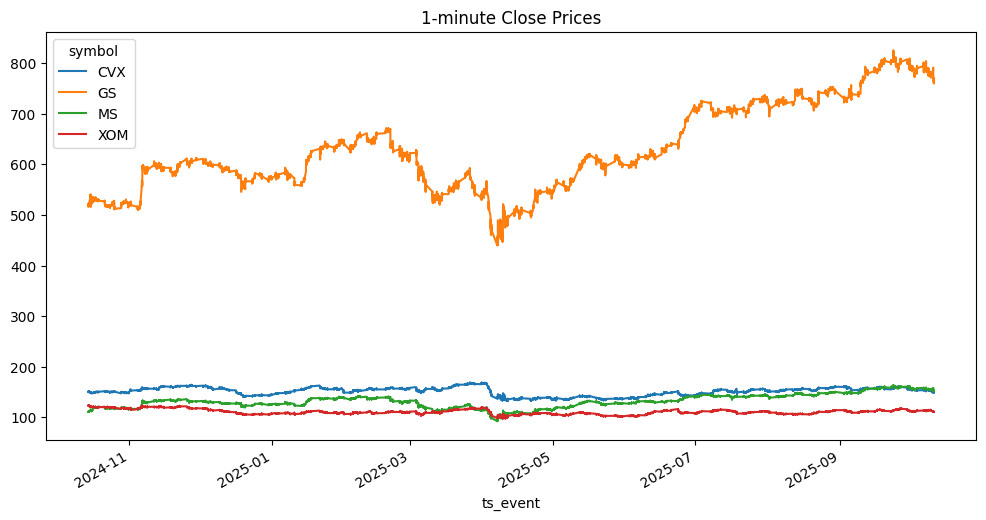

In [8]:
import matplotlib.pyplot as plt
prices.plot(figsize=(12,6), title="1-minute Close Prices")
plt.show()


In [10]:
from itertools import combinations
from statsmodels.tsa.stattools import coint

results = []
for s1, s2 in combinations(prices.columns, 2):
    score, pvalue, _ = coint(prices[s1], prices[s2])
    results.append((s1, s2, pvalue))

coint_df = pd.DataFrame(results, columns=["Symbol1", "Symbol2", "pvalue"]).sort_values("pvalue")
coint_df


,Symbol1,Symbol2,pvalue
3,GS,MS,0.146560
2,CVX,XOM,0.277483
1,CVX,MS,0.450958
0,CVX,GS,0.466535
5,MS,XOM,0.666534
4,GS,XOM,0.907089


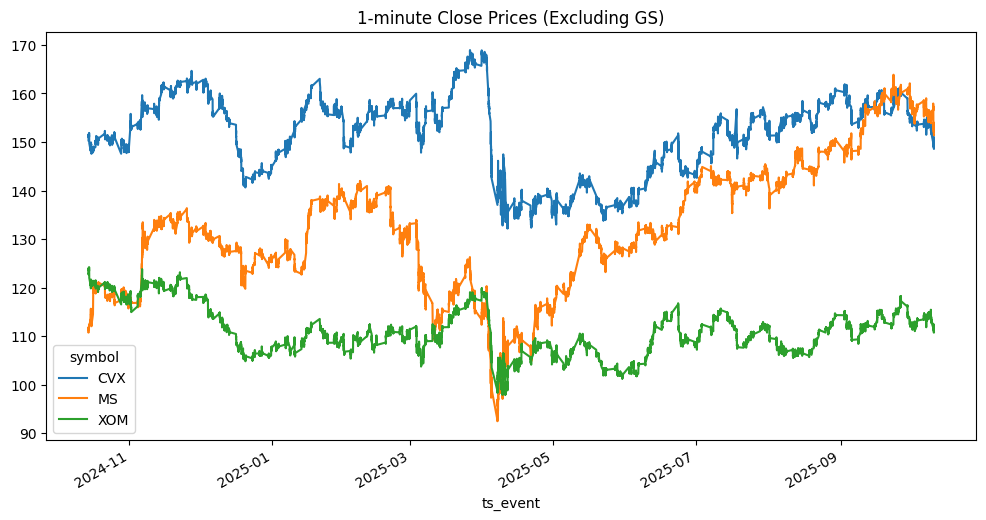

In [15]:
import matplotlib.pyplot as plt

prices.drop(columns="GS").plot(figsize=(12,6), title="1-minute Close Prices (Excluding GS)")
plt.show()


In [13]:
import statsmodels.api as sm
y = prices[s1]
x = sm.add_constant(prices[s2])
beta = sm.OLS(y, x).fit().params[1]
beta


/var/folders/wy/ttk8wx_17bz5_tqgb_vfcb9c0000gn/T/ipykernel_68001/962109975.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta = sm.OLS(y, x).fit().params[1]


np.float64(0.5749991279904823)

In [16]:
import pandas as pd
from itertools import combinations
from statsmodels.tsa.stattools import coint

# Optionally drop GS if still in the DataFrame
symbols = [c for c in prices.columns if c != "GS"]
subset = prices[symbols].dropna(how="any")

# ----- 1. Pairwise CORRELATION -----
corr_matrix = subset.corr()
print("Pairwise Correlation Matrix:")
print(corr_matrix)
print()

# ----- 2. Pairwise COINTEGRATION -----
results = []
for s1, s2 in combinations(subset.columns, 2):
    score, pvalue, _ = coint(subset[s1], subset[s2])
    results.append((s1, s2, pvalue))

coint_df = pd.DataFrame(results, columns=["Symbol1", "Symbol2", "pvalue"]).sort_values("pvalue")
print("Pairwise Cointegration Test Results (Engle–Granger):")
print(coint_df)


Pairwise Correlation Matrix:
symbol       CVX        MS       XOM
symbol                              
CVX     1.000000  0.387043  0.680101
MS      0.387043  1.000000  0.129218
XOM     0.680101  0.129218  1.000000

Pairwise Cointegration Test Results (Engle–Granger):
  Symbol1 Symbol2    pvalue
1     CVX     XOM  0.277483
0     CVX      MS  0.450958
2      MS     XOM  0.666534
